In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Data (I had to include and encoding fix)
df_2024 = pd.read_csv(
    "/kaggle/input/datasets/mredondohz/stl-cardinals24-25/Stl_cardinals_stats/stl_cardinals_2024.csv",
    encoding="latin1"
)

df_2025 = pd.read_csv(
    "/kaggle/input/datasets/mredondohz/stl-cardinals24-25/Stl_cardinals_stats/stl_cardinals_2025.csv",
    encoding="latin1"
)

# Combine datasets
df = pd.concat([df_2024, df_2025])

df.head()

,Player,AVG,PA,OBP,SLG,OPS,Season
0,Pedro Pagés,0.238,218,0.281,0.376,0.657,2024
1,Paul Goldschmidt,0.245,654,0.302,0.414,0.716,2024
2,Nolan Gorman,0.203,402,0.271,0.400,0.671,2024
3,Masyn Winn,0.267,637,0.314,0.416,0.730,2024
4,Nolan Arenado,0.272,635,0.325,0.394,0.719,2024


In [3]:
# Check data types
df.info()

# Convert to numeric (I did it just to be safe)
df["AVG"] = pd.to_numeric(df["AVG"], errors="coerce")
df["OPS"] = pd.to_numeric(df["OPS"], errors="coerce")
df["PA"] = pd.to_numeric(df["PA"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["AVG", "OPS", "PA"])

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 0 to 21
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  42 non-null     object 
 1   AVG     42 non-null     float64
 2   PA      42 non-null     int64  
 3   OBP     42 non-null     float64
 4   SLG     42 non-null     float64
 5   OPS     42 non-null     float64
 6   Season  42 non-null     int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 2.6+ KB


,AVG,PA,OBP,SLG,OPS,Season
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,0.220833,290.071429,0.288643,0.341000,0.629500,2024.523810
std,0.051461,221.013342,0.059750,0.091473,0.143297,0.505487
min,0.077000,6.000000,0.133000,0.077000,0.271000,2024.000000
25%,0.198750,71.750000,0.262250,0.283500,0.552250,2024.000000
50%,0.232500,277.000000,0.292500,0.367000,0.661500,2025.000000
75%,0.257750,460.250000,0.325000,0.415500,0.727250,2025.000000
max,0.301000,654.000000,0.380000,0.468000,0.848000,2025.000000


In [4]:
# Create rankings
df["OPS_rank"] = df["OPS"].rank(ascending=False)
df["PA_rank"] = df["PA"].rank(ascending=False)

# Gap = OPS_rank - PA_rank (compares offensive performance with playing time)
df["Gap"] = df["OPS_rank"] - df["PA_rank"]

df.head()

,Player,AVG,PA,OBP,SLG,OPS,Season,OPS_rank,PA_rank,Gap
0,Pedro Pagés,0.238,218,0.281,0.376,0.657,2024,22.0,23.0,-1.0
1,Paul Goldschmidt,0.245,654,0.302,0.414,0.716,2024,13.0,1.0,12.0
2,Nolan Gorman,0.203,402,0.271,0.400,0.671,2024,19.0,15.5,3.5
3,Masyn Winn,0.267,637,0.314,0.416,0.730,2024,11.0,3.0,8.0
4,Nolan Arenado,0.272,635,0.325,0.394,0.719,2024,12.0,4.0,8.0


In [5]:
# Identify undervalued and overvalued players

# Undervalued players (low Gap: strong performance, limited playing time)
undervalued = df.sort_values(by="Gap").head(5)

# Overvalued players (high Gap: lower performance, higher playing time)
overvalued = df.sort_values(by="Gap", ascending=False).head(5)

# Display results
display(undervalued)
display(overvalued)

,Player,AVG,PA,OBP,SLG,OPS,Season,OPS_rank,PA_rank,Gap
13,José Fermín,0.283,70,0.377,0.417,0.793,2025,5.0,32.0,-27.0
16,Luken Baker,0.235,41,0.366,0.324,0.689,2025,14.0,37.0,-23.0
19,Luken Baker,0.175,49,0.286,0.400,0.686,2024,16.0,35.0,-19.0
10,Iván Herrera,0.301,259,0.372,0.428,0.800,2024,4.0,22.0,-18.0
9,Willson Contreras,0.262,358,0.380,0.468,0.848,2024,1.0,19.0,-18.0


,Player,AVG,PA,OBP,SLG,OPS,Season,OPS_rank,PA_rank,Gap
6,Victor Scott II,0.216,463,0.305,0.296,0.601,2025,28.0,11.0,17.0
1,Paul Goldschmidt,0.245,654,0.302,0.414,0.716,2024,13.0,1.0,12.0
7,Jordan Walker,0.215,396,0.278,0.306,0.584,2025,29.0,17.0,12.0
5,Lars Nootbaar,0.234,583,0.325,0.361,0.686,2025,16.0,6.0,10.0
6,Michael Siani,0.228,334,0.285,0.285,0.570,2024,30.0,20.0,10.0


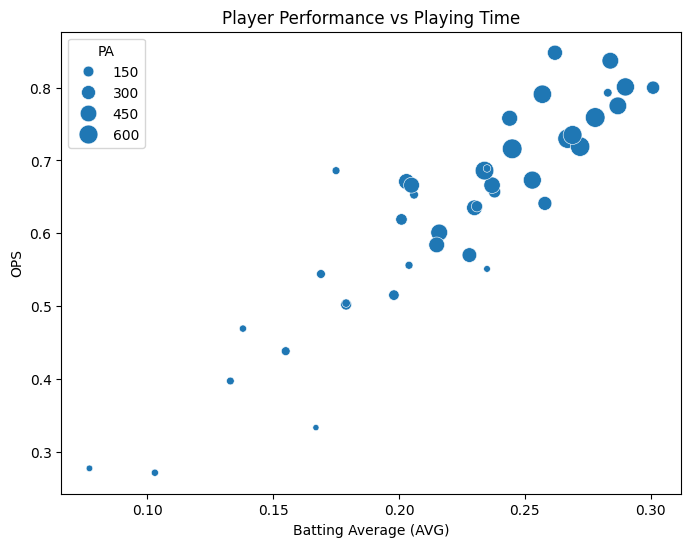

In [6]:
# Scatter plot: Player Performance vs Playing Time

# Create visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="AVG",
    y="OPS",
    size="PA",
    sizes=(20, 200)
)

# Customize chart
plt.title("Player Performance vs Playing Time")
plt.xlabel("Batting Average (AVG)")
plt.ylabel("OPS")

# Display chart
plt.show()

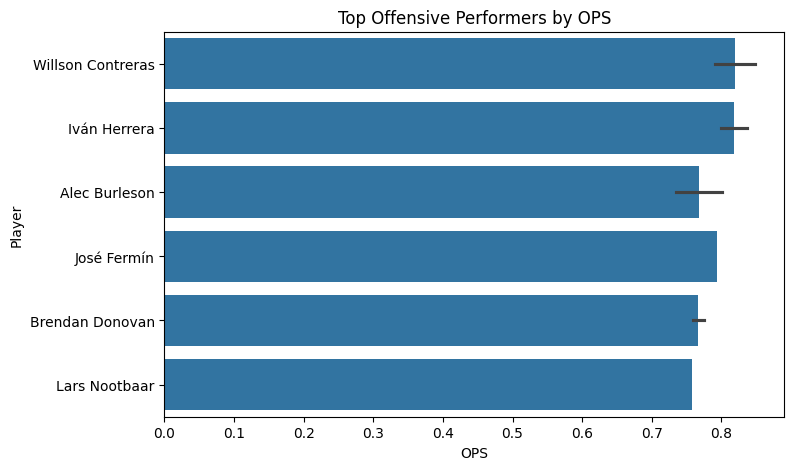

In [7]:
# Bar chart: Top offensive performers based on OPS

# Select top players by OPS
top_players = df.sort_values(by="OPS", ascending=False).head(10)

# Create visualization
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_players,
    x="OPS",
    y="Player"
)

# Customize chart
plt.title("Top Offensive Performers by OPS")
plt.xlabel("OPS")
plt.ylabel("Player")

# Display chart
plt.show()